# Large scale Gauss-Newton

Let's try it on a ViT model with layers using the layer formulation. 

## Imports and data

In [1]:
from timeit import timeit

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp
from typing import Sequence, List, Tuple, Callable
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import itertools
from jax.scipy.linalg import block_diag
import optax
from datasets import load_dataset
from functools import partial


from jax import random
# Seeding for random operations
main_rng = random.PRNGKey(42)

# For viz
import treescope
treescope.basic_interactive_setup(
    autovisualize_arrays=True,
    abbreviation_threshold=2, 
)
treescope.register_as_default()


In [2]:
def get_datasets():
    """Load MNIST train and test datasets into memory."""
    # Load the MNIST dataset
    dataset = load_dataset('mnist')

    # Convert datasets to numpy arrays
    train_ds = {
        'image': jnp.array(dataset['train']['image']),
        'label': jnp.array(dataset['train']['label'])
    }
    test_ds = {
        'image': jnp.array(dataset['test']['image']),
        'label': jnp.array(dataset['test']['label'])
    }

    # Normalize the images
    train_ds['image'] = train_ds['image'].astype(jnp.float32) / 255.0
    test_ds['image'] = test_ds['image'].astype(jnp.float32) / 255.0

    # Reshape to mimic 3D
    train_ds['image'] = jnp.expand_dims(train_ds['image'], axis=-1)
    test_ds['image'] = jnp.expand_dims(test_ds['image'], axis=-1)


    return train_ds, test_ds

In [3]:
# Get datasets as dict of JAX arrays.
train_ds, test_ds = get_datasets()

In [4]:
def img_to_patch(x, patch_size, flatten_channels=True):
    """
    Inputs:
        x - torch.Tensor representing the image of shape [B, H, W, C]
        patch_size - Number of pixels per dimension of the patches (integer)
        flatten_channels - If True, the patches will be returned in a flattened format
                           as a feature vector instead of a image grid.
    """
    B, H, W, C = x.shape
    x = x.reshape(B, H//patch_size, patch_size, W//patch_size, patch_size, C)
    x = x.transpose(0, 1, 3, 2, 4, 5)    # [B, H', W', p_H, p_W, C]
    x = x.reshape(B, -1, *x.shape[3:])   # [B, H'*W', p_H, p_W, C]
    if flatten_channels:
        x = x.reshape(B, x.shape[1], -1) # [B, H'*W', p_H*p_W*C]
    return x

In [5]:
class AttentionBlock(nn.Module):
    embed_dim : int   # Dimensionality of input and attention feature vectors
    hidden_dim : int  # Dimensionality of hidden layer in feed-forward network
    num_heads : int   # Number of heads to use in the Multi-Head Attention block
    # dropout_prob : float = 0.0  # Amount of dropout to apply in the feed-forward network

    def setup(self):
        self.attn = nn.MultiHeadDotProductAttention(num_heads=self.num_heads)
        self.linear = [
            nn.Dense(self.hidden_dim),
            nn.gelu,
            # nn.Dropout(self.dropout_prob),
            nn.Dense(self.embed_dim)
        ]
        self.layer_norm_1 = nn.LayerNorm()
        self.layer_norm_2 = nn.LayerNorm()
        # self.dropout = nn.Dropout(self.dropout_prob)

    def __call__(self, x):
        inp_x = self.layer_norm_1(x)
        attn_out = self.attn(inputs_q=inp_x, inputs_kv=inp_x)
        # x = x + self.dropout(attn_out, deterministic=not train)
        x = x + attn_out

        linear_out = self.layer_norm_2(x)
        for l in self.linear:
            linear_out = l(linear_out)
        # x = x + self.dropout(linear_out, deterministic=not train)
        x = x + linear_out
        
        return x

In [6]:
class Preprocessor(nn.Module):
    embed_dim: int
    patch_size: int
    num_patches: int

    def setup(self):
        self.input_layer = nn.Dense(self.embed_dim)
        self.pos_embedding = self.param('pos_embedding',
                                        nn.initializers.normal(stddev=1.0),
                                        (1, 1 + self.num_patches, self.embed_dim))
        self.cls_token = self.param('cls_token',
                                    nn.initializers.normal(stddev=1.0),
                                    (1, 1, self.embed_dim))

    def __call__(self, x):
        # Preprocess input
        x = img_to_patch(x, self.patch_size)
        B, T, _ = x.shape
        x = self.input_layer(x)

        # Add CLS token and positional encoding
        cls_token = self.cls_token.repeat(B, axis=0)
        x = jnp.concatenate([cls_token, x], axis=1)
        x = x + self.pos_embedding[:, :T + 1]
        return x


class ClassificationHead(nn.Module):
    embed_dim: int
    num_classes: int

    def setup(self):
        self.mlp_head = nn.Sequential([
            nn.LayerNorm(),
            nn.Dense(self.num_classes)
        ])

    def __call__(self, x):
        # Perform classification prediction
        cls = x[:, 0]
        out = self.mlp_head(cls)
        return out


class VisionTransformer(nn.Module):
    embed_dim: int     # Dimensionality of input and attention feature vectors
    hidden_dim: int    # Dimensionality of hidden layer in feed-forward network
    num_heads: int     # Number of heads to use in the Multi-Head Attention block
    num_channels: int  # Number of channels of the input (3 for RGB)
    num_layers: int    # Number of layers to use in the Transformer
    num_classes: int   # Number of classes to predict
    patch_size: int    # Number of pixels that the patches have per dimension
    num_patches: int   # Maximum number of patches an image can have
    # dropout_prob: float = 0.0  # Amount of dropout to apply in the feed-forward network

    def setup(self):
        # All layers
        self.layers = [Preprocessor(self.embed_dim, self.patch_size, self.num_patches)] + [
            AttentionBlock(self.embed_dim,
                                           self.hidden_dim,
                                           self.num_heads,
                                           ) for _ in range(self.num_layers)
        ] + [ClassificationHead(self.embed_dim, self.num_classes)]


    def __call__(self, x, layer_out: bool = False) -> Tuple[jax.Array, List[jax.Array]]:
        intermediate_inputs = [x]
        y = x
        
        # Apply Transformer
        for i, layer in enumerate(self.layers):
            y = layer(y)
            y = self.perturb(f'layer_{i+1}', y)
            intermediate_inputs.append(y)
            
        # The final `y` is the final output. The inputs list is one item too long.
        final_output = intermediate_inputs.pop()

        if not layer_out:
            return final_output
            
        return final_output, intermediate_inputs


    def get_jacobian_calculators(self) -> List[Callable]:
        """
        Creates a list of functions that compute the Jacobian of each layer's
        output with respect to its parameters.

        This method is called via `model.apply(..., method=...)`, which ensures
        that `self.layers` is available.

        Adapted for VisualTransformer, noting that the middle layers are the same functions as they're all 
        just self-attention. 
        """
        jacobian_fns = []

        def layer_apply_fn(layer_instance: nn.Module, params: dict, layer_input: jax.Array) -> jax.Array:
            """A wrapper to call a single layer's apply method."""
            return layer_instance.apply({'params': params}, layer_input)

        # Compute Jacobian for the preprocessor layer
        # jacobian_fns.append(jax.jacrev(partial(layer_apply_fn, self.layers[0]), argnums=0))
        jacobian_fns.append(jax.jacfwd(partial(layer_apply_fn, self.layers[0]), argnums=0))
    
        # Compute Jacobian for one representative attention block
        attention_block = self.layers[1]  # Assuming all middle layers are identical
        # attention_jac_fn = jax.jacrev(partial(layer_apply_fn, attention_block), argnums=0)
        attention_jac_fn = jax.jacfwd(partial(layer_apply_fn, attention_block), argnums=0)
    
        # Reuse the Jacobian function for all identical attention blocks
        jacobian_fns.extend([attention_jac_fn] * self.num_layers)
    
        # Compute Jacobian for the classification head
        # jacobian_fns.append(jax.jacrev(partial(layer_apply_fn, self.layers[-1]), argnums=0))
        jacobian_fns.append(jax.jacfwd(partial(layer_apply_fn, self.layers[-1]), argnums=0))

        return jacobian_fns



In [7]:
main_rng, x_rng = random.split(main_rng)
# x = random.normal(x_rng, (1, 28, 28, 1))
x = train_ds['image'][0:64]

visntrans = VisionTransformer(embed_dim=8, # Make these numbers small for testing first
                              hidden_dim=32,
                              num_heads=4,
                              num_channels=1,
                              num_layers=4,
                              num_classes=10,
                              patch_size=4,
                              num_patches=49,
                             )

# Initialize parameters of the Vision Transformer with random key and inputs
key = jax.random.PRNGKey(0)
params = visntrans.init({'params': key}, x)
params, perturbations = params['params'], params['perturbations']

main_rng, dropout_apply_rng = random.split(main_rng)
out = visntrans.apply({'params': params}, x, layer_out=True)
print('Out', out[0].shape)

# del visntrans, params

Out (64, 10)


In [8]:
jacobian_calculators = visntrans.apply({'params': params}, method=visntrans.get_jacobian_calculators)
print(f"Created {len(jacobian_calculators)} Jacobian functions.")

Created 6 Jacobian functions.


In [9]:
jacobian_calculators

[<function functools.layer_apply_fn(params: dict, layer_input: jax.Array) -> jax.Array>,
 <function functools.layer_apply_fn(params: dict, layer_input: jax.Array) -> jax.Array>,
 <function functools.layer_apply_fn(params: dict, layer_input: jax.Array) -> jax.Array>,
 <function functools.layer_apply_fn(params: dict, layer_input: jax.Array) -> jax.Array>,
 <function functools.layer_apply_fn(params: dict, layer_input: jax.Array) -> jax.Array>,
 <function functools.layer_apply_fn(params: dict, layer_input: jax.Array) -> jax.Array>]

In [10]:
stored_jacobians_for_step = []
for i, (jac_fn, layer_input) in enumerate(zip(jacobian_calculators, out[1])):
    layer_params = params[f'layers_{i}']

    # Calculate the Jacobian: ∂L_i/∂θ_i evaluated at y_{i-1}
    jacobian_pytree = jac_fn(layer_params, layer_input)
    stored_jacobians_for_step.append(jacobian_pytree)

    print(f"\n--- Layer {i} (Dense_{i}) ---")
    print(f"Input shape (y_{i-1}): {layer_input.shape}")
    print(f'{jacobian_pytree.keys()}')

    # if i == 1: 
    #     break
# %timeit jac_fn(layer_params, layer_input)


--- Layer 0 (Dense_0) ---
Input shape (y_-1): (64, 28, 28, 1)
dict_keys(['cls_token', 'input_layer', 'pos_embedding'])

--- Layer 1 (Dense_1) ---
Input shape (y_0): (64, 50, 8)
dict_keys(['attn', 'layer_norm_1', 'layer_norm_2', 'linear_0', 'linear_2'])

--- Layer 2 (Dense_2) ---
Input shape (y_1): (64, 50, 8)
dict_keys(['attn', 'layer_norm_1', 'layer_norm_2', 'linear_0', 'linear_2'])

--- Layer 3 (Dense_3) ---
Input shape (y_2): (64, 50, 8)
dict_keys(['attn', 'layer_norm_1', 'layer_norm_2', 'linear_0', 'linear_2'])

--- Layer 4 (Dense_4) ---
Input shape (y_3): (64, 50, 8)
dict_keys(['attn', 'layer_norm_1', 'layer_norm_2', 'linear_0', 'linear_2'])

--- Layer 5 (Dense_5) ---
Input shape (y_4): (64, 50, 8)
dict_keys(['mlp_head'])


In [11]:
sum(x.size for x in jax.tree_util.tree_leaves(params[f'layers_{i}'])) 

106

In [12]:

total_params = sum(x.size for x in jax.tree_util.tree_leaves(params))

# Print the number of parameters
print(f"Number of parameters: {total_params}")

Number of parameters: 4138


### Verification 

I want to verify that I can calculate the Jacobian using the decomposition easily. We first create the Jacobian of the model. 

#### Calculate Jacobian regularly 

In [13]:
n_samples = x.shape[0]

In [14]:
# jacobian = jax.jacobian(
#     lambda *args, **kwargs: visntrans.apply(*args, **kwargs)[0],
#     argnums=0)(
#     {'params': params}, 
#     x
# )
jacobian = jax.jacobian(
    lambda params, perturbations, X: visntrans.apply(
        {'params': params, 'perturbations': perturbations}, X
    ),
    argnums=0
)(
    params, perturbations, x
)

flattened, _ = jax.tree.flatten(
    jacobian
)

reshaped_leaves = [leaf.reshape(n_samples * 10, 1, -1) for leaf in flattened]
aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
J = aggregated_array.reshape((n_samples * 10, -1))


In [15]:
J

Array([[ 0.28224588, -0.1519157 ,  0.48886284, ...,  0.        ,
         0.        ,  0.        ],
       [-0.02336005, -0.02939429,  0.6297337 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.12102663, -0.19729381,  0.101822  , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.17111534, -0.07151756, -0.1398606 , ..., -0.77519292,
         0.        ,  0.        ],
       [ 0.18155157, -0.06638353,  0.08385421, ...,  0.        ,
        -0.77519292,  0.        ],
       [ 0.65645567, -1.00837575,  0.0541624 , ...,  0.        ,
         0.        , -0.77519292]], dtype=float64)

In [21]:
# Grab the condition number 
probs = jax.nn.softmax(out[0], axis=-1).flatten()
diag_probs_inv = jnp.diag(1 / probs)  # Inverse of the diagonal matrix
outer_probs = jnp.outer(probs, probs)
denominator = 1 - jnp.dot(probs, jnp.dot(diag_probs_inv, probs))
numerator = jnp.dot(diag_probs_inv, outer_probs) @ diag_probs_inv
H_inv = diag_probs_inv + numerator / denominator

jnp.linalg.eigvalsh(H_inv + J @ J.T / 0.1) 

Array([2.07129508e+00, 2.10315858e+00, 2.10804466e+00, 2.13817484e+00,
       2.15398964e+00, 2.16029803e+00, 2.16847731e+00, 2.18324843e+00,
       2.19006168e+00, 2.22883622e+00, 2.23748131e+00, 2.24918196e+00,
       2.26125928e+00, 2.28134729e+00, 2.29895023e+00, 2.30442802e+00,
       2.32485858e+00, 2.36918541e+00, 2.39498956e+00, 2.41328213e+00,
       2.42513897e+00, 2.46449287e+00, 2.50046355e+00, 2.51818202e+00,
       2.53556082e+00, 2.55741943e+00, 2.58091618e+00, 2.61915660e+00,
       2.66845611e+00, 2.69304217e+00, 2.71760643e+00, 2.73230838e+00,
       2.79260990e+00, 2.82286905e+00, 2.89758387e+00, 2.97185983e+00,
       2.97975570e+00, 3.00776469e+00, 3.07154315e+00, 3.20264964e+00,
       3.27263401e+00, 3.30129262e+00, 3.33057997e+00, 3.47538133e+00,
       3.57168121e+00, 3.63303820e+00, 3.64127478e+00, 3.82090114e+00,
       3.95405296e+00, 4.13524578e+00, 4.18893880e+00, 4.36034539e+00,
       4.50914948e+00, 4.72368481e+00, 4.87236204e+00, 4.95211066e+00,
       5.45511746e+00, 6.02678561e+00, 6.40309646e+00, 7.97245187e+00,
       8.11034629e+00, 8.20474723e+00, 8.32106474e+00, 8.35744389e+00,
       8.41088540e+00, 8.43139600e+00, 8.43661339e+00, 8.45598436e+00,
       8.47788946e+00, 8.51277928e+00, 8.52801980e+00, 8.56741676e+00,
       8.60465431e+00, 8.63143036e+00, 8.63986261e+00, 8.66539514e+00,
       8.69680784e+00, 8.72598759e+00, 8.75578621e+00, 8.78435870e+00,
       8.80283447e+00, 8.82663080e+00, 8.83167563e+00, 8.88229286e+00,
       8.91272335e+00, 8.96901259e+00, 9.01839091e+00, 9.05458323e+00,
       9.08911743e+00, 9.10967756e+00, 9.13945942e+00, 9.19237543e+00,
       9.22510880e+00, 9.27695588e+00, 9.32050867e+00, 9.36039778e+00,
       9.46290974e+00, 9.51034375e+00, 9.54957964e+00, 9.58649929e+00,
       9.60582944e+00, 9.78202206e+00, 9.79510306e+00, 9.86771539e+00,
       9.93199416e+00, 9.99754652e+00, 1.00174403e+01, 1.00796292e+01,
       1.01435204e+01, 1.02232790e+01, 1.02676736e+01, 1.03089471e+01,
       1.04419088e+01, 1.04902581e+01, 1.05618761e+01, 1.06314302e+01,
       1.07132826e+01, 1.07793149e+01, 1.08432215e+01, 1.09152179e+01,
       1.10108856e+01, 1.10627946e+01, 1.11923200e+01, 1.13250741e+01,
       1.13454042e+01, 1.14649270e+01, 1.15119578e+01, 1.15503506e+01,
       1.16111125e+01, 1.16461193e+01, 1.17103704e+01, 1.17520660e+01,
       1.19562190e+01, 1.19948008e+01, 1.20385458e+01, 1.20750230e+01,
       1.21942905e+01, 1.22364432e+01, 1.23011811e+01, 1.23984506e+01,
       1.24261791e+01, 1.24974689e+01, 1.25970980e+01, 1.26472584e+01,
       1.27318420e+01, 1.27724453e+01, 1.28035834e+01, 1.28181893e+01,
       1.28995322e+01, 1.29472499e+01, 1.29885661e+01, 1.30023233e+01,
       1.30307938e+01, 1.30413580e+01, 1.30535794e+01, 1.30643263e+01,
       1.30856144e+01, 1.31178645e+01, 1.31400564e+01, 1.31530216e+01,
       1.31600141e+01, 1.31909775e+01, 1.31987808e+01, 1.32215420e+01,
       1.32376557e+01, 1.32690775e+01, 1.32755804e+01, 1.33112373e+01,
       1.33164141e+01, 1.33417899e+01, 1.33713774e+01, 1.34087206e+01,
       1.34244268e+01, 1.34297007e+01, 1.34622271e+01, 1.34775007e+01,
       1.35034565e+01, 1.35261100e+01, 1.35445754e+01, 1.35634348e+01,
       1.35757309e+01, 1.36514523e+01, 1.36664307e+01, 1.36896323e+01,
       1.37044557e+01, 1.37356472e+01, 1.38066770e+01, 1.38298475e+01,
       1.38995095e+01, 1.39399265e+01, 1.39614613e+01, 1.40128120e+01,
       1.40196826e+01, 1.40845023e+01, 1.41408975e+01, 1.41946409e+01,
       1.42489910e+01, 1.42626895e+01, 1.43713224e+01, 1.44136975e+01,
       1.45074765e+01, 1.45769733e+01, 1.47456031e+01, 1.47957782e+01,
       1.48786633e+01, 1.49334801e+01, 1.49885170e+01, 1.50470458e+01,
       1.51743570e+01, 1.53717153e+01, 1.54855815e+01, 1.56168667e+01,
       1.58731321e+01, 1.59754914e+01, 1.61522758e+01, 1.65156386e+01,
       1.69832109e+01, 1.71176220e+01, 1.73505250e+01, 1.75669712e+01,
       1.78951207e+01, 1.82150840e+01, 1.84630385e+01, 1.85307256e+01,
       1.88856533e+01, 1

#### Use the adjoints 

In [101]:
# To grab the gradient wrt to the adjoints/residuals, we take the Jacobian wrt to the perturbations!
jacobian = jax.jacobian(
    lambda params, perturbations, X: visntrans.apply(
        {'params': params, 'perturbations': perturbations}, X
    ),
    argnums=1
)(
    params, perturbations, x
)
flattened, _ = jax.tree.flatten(
    jacobian
)
# for leaf in flattened: 
#     print(leaf.shape)
# It's weird that the perturbations are this dimensions, but it's easy to reshape them to what we need
together = [leaf.reshape((leaf.shape[0] * leaf.shape[1], -1)) for leaf in flattened]
global_adjoints = together
treescope.display(together)
# global_adjoints = [
#     block_diag(*jnp.split(leaf, n_samples, axis=0)) for leaf in together
# ]




In [102]:
layers = []
for i, layer in enumerate(stored_jacobians_for_step):
    layer_weights = jax.tree.flatten(layer)[0]
    layer_weights = [weights.reshape((global_adjoints[i].shape[1], -1)) for weights in layer_weights]
    layer_weights = jnp.concatenate(layer_weights, axis=-1)
    layers.append(layer_weights)
    

In [104]:
layers

[<jax.Array float32(25600, 544)- too large to summarize.
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float32(25600, 872)- too large to summarize.
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float32(25600, 872)- too large to summarize.
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float32(25600, 872)- too large to summarize.
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float32(25600, 872)- too large to summarize.
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float32(640, 106) ≈0.016 ±0.32 [≥-1.5, ≤1.9] zero:51_840 nonzero:16_000
   <Arrayviz rendering>
 | Device: GPU 0>]

In [105]:
my_J = []
for i, (a, b) in enumerate(zip(global_adjoints, layers)):
    my_J.append(a @ b)
my_J = jnp.concatenate(my_J, axis=-1)
my_J

<jax.Array float32(640, 4138) ≈0.00068 ±0.14 [≥-1.8, ≤2.2] zero:51_840 nonzero:2_596_480
  <Arrayviz rendering>
| Device: GPU 0>

In [106]:
J

<jax.Array float32(640, 4138) ≈0.00068 ±0.14 [≥-1.8, ≤2.2] zero:51_845 nonzero:2_596_475
  <Arrayviz rendering>
| Device: GPU 0>

In [110]:
jnp.linalg.norm(my_J - J) / jnp.linalg.norm(J)

<jax.Array(0.00054982, dtype=float32)>

In [23]:
def get_correction(k_list, global_adjoints, grad, H_inv, lamb: float=1e-1):
    """
    Assumes grad is a vector
    """
    p_list = [k.shape[1] for k in k_list]
    p_list.insert(0, 0)
    indices = list(itertools.accumulate(p_list))
    j_shape = global_adjoints[0].shape[0]

    # Use the SMW formulation; first do Jv
    aux_var = jnp.zeros(j_shape)
    for i in range(len(k_list)):
        aux_var += global_adjoints[i] @ (k_list[i] @ grad[indices[i]:indices[i+1]])
    # treescope.display(aux_var)
    
    # Calculate I + 1 / lamb JJ^T and get its inverse
    # sum_mat = jnp.eye(j_shape)
    sum_mat = H_inv
    for i in range(len(k_list)):
        sum_mat += global_adjoints[i] @ (k_list[i] @ k_list[i].T) @ global_adjoints[i].T / lamb
    aux_var = jnp.linalg.solve(sum_mat, aux_var)
    
    # Finally do J^T v and scale
    out = jnp.concat([k_list[i].T @ (global_adjoints[i].T @ aux_var) for i in range(len(k_list))]) / (lamb ** 2)
    # treescope.display(out)
    # Don't forget the 1/lambda I
    return -out + grad / lamb


In [111]:
grad = jnp.arange(J.shape[1],) * 2

probs = jax.nn.softmax(out[0], axis=-1).flatten()
diag_probs = jnp.diag(probs)
outer_probs = jnp.outer(probs, probs)
H = diag_probs - outer_probs
H_inv = jnp.linalg.inv(H)
# H = jnp.eye(H.shape[0])
# H_inv = H
# treescope.display(H_inv @ H)

corrected = get_correction(layers, global_adjoints, grad, H_inv, 0.1)
true = jnp.linalg.solve(J.T @ H @ J + 0.1 *  jnp.eye(J.shape[1]), grad)

print(jnp.linalg.norm(corrected - true) / jnp.linalg.norm(true))
treescope.display(corrected)
treescope.display(true)

0.0021759481


In [45]:
# To grab the gradient wrt to the adjoints/residuals, we take the Jacobian wrt to the perturbations!
jacobian = jax.jacobian(
    lambda params, perturbations, X: visntrans.apply(
        {'params': params, 'perturbations': perturbations}, X
    ),
    argnums=1
)(
    params, perturbations, x
)
flattened, _ = jax.tree.flatten(
    jacobian
)
for leaf in flattened: 
    print(leaf.shape)


(10, 10, 10, 50, 8)
(10, 10, 10, 50, 8)
(10, 10, 10, 50, 8)
(10, 10, 10, 50, 8)
(10, 10, 10, 50, 8)
(10, 10, 10, 10)


In [46]:
# jacobian = jax.jacobian(
#     lambda params, perturbations, X: visntrans.apply(
#         {'params': params, 'perturbations': perturbations}, X
#     ),
#     argnums=1
# )(
#     params, perturbations, x
# )

# primals, vjp_fun = jax.vjp(
#     lambda perturbations: visntrans.apply(
#         {'params': params, 'perturbations': perturbations}, x
#     ),
#     perturbations
# )
# vjp_fun(primals)

jax.jvp(
    lambda perturbations: visntrans.apply(
        {'params': params, 'perturbations': perturbations}, x
    ),
    (perturbations,), 
    (perturbations,)
)
perturbations

{'layer_1': <jax.Array float32(10, 50, 8) ≈0.0 ±0.0 [≥0.0, ≤0.0] zero:4_000
   <Arrayviz rendering>
 | Device: GPU 0>,
 'layer_2': <jax.Array float32(10, 50, 8) ≈0.0 ±0.0 [≥0.0, ≤0.0] zero:4_000
   <Arrayviz rendering>
 | Device: GPU 0>,
 'layer_3': <jax.Array float32(10, 50, 8) ≈0.0 ±0.0 [≥0.0, ≤0.0] zero:4_000
   <Arrayviz rendering>
 | Device: GPU 0>,
 'layer_4': <jax.Array float32(10, 50, 8) ≈0.0 ±0.0 [≥0.0, ≤0.0] zero:4_000
   <Arrayviz rendering>
 | Device: GPU 0>,
 'layer_5': <jax.Array float32(10, 50, 8) ≈0.0 ±0.0 [≥0.0, ≤0.0] zero:4_000
   <Arrayviz rendering>
 | Device: GPU 0>,
 'layer_6': <jax.Array float32(10, 10) ≈0.0 ±0.0 [≥0.0, ≤0.0] zero:100
   <Arrayviz rendering>
 | Device: GPU 0>}

In [48]:
layers = []
for i, layer in enumerate(stored_jacobians_for_step):
    layer_weights = jax.tree.flatten(layer)[0]
    if i < 5:
        layer_weights = [weights.reshape((2,50, -1)) for weights in layer_weights]
    else:
        layer_weights = [weights.reshape((2, 10, -1)) for weights in layer_weights]
    layer_weights = jnp.concatenate(layer_weights, axis=-1)
    layers.append(layer_weights)
    
layers

[<jax.Array float32(2, 50, 21760) ≈0.0071 ±0.081 [≥0.0, ≤1.0] zero:2_156_968 nonzero:19_032
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float32(2, 50, 34880) ≈0.012 ±0.18 [≥-2.5, ≤2.9] zero:924_000 nonzero:2_564_000
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float32(2, 50, 34880) ≈0.011 ±0.19 [≥-3.0, ≤3.2] zero:924_000 nonzero:2_564_000
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float32(2, 50, 34880) ≈0.012 ±0.19 [≥-2.7, ≤3.5] zero:924_000 nonzero:2_564_000
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float32(2, 50, 34880) ≈0.011 ±0.18 [≥-2.0, ≤3.1] zero:924_000 nonzero:2_564_000
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float32(2, 10, 530) ≈-0.0025 ±0.32 [≥-1.6, ≤2.1] zero:8_100 nonzero:2_500
   <Arrayviz rendering>
 | Device: GPU 0>]

## Train using just SGD

In [ ]:
def train_model_sgd(train_ds, model, params, learning_rate, num_epochs,
                   bsz:int = 32):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    # optimizer = optax.adam(learning_rate / 5)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )

    @jax.jit
    def train_step(state, batch_X, labels):
        def loss_fn(params):
            logits = state.apply_fn(params, batch_X)
            one_hot = jax.nn.one_hot(labels, 10)
            loss = jnp.mean(optax.softmax_cross_entropy(logits=logits, labels=one_hot))
            return loss, logits

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, logits), grads = grad_fn({'params': state.params})
        state = state.apply_gradients(grads=grads['params'])

        accuracy = jnp.mean(jnp.argmax(logits, -1) == labels)
        return state, loss, accuracy

    print(f"Starting training for {num_epochs} epochs...")
    
    train_ds_size = len(train_ds['image'])
    steps_per_epoch = train_ds_size // bsz

    rng = jax.random.PRNGKey(0)
    perms = jax.random.permutation(rng, len(train_ds['image']))
    perms = perms[: steps_per_epoch * bsz]  # skip incomplete batch
    perms = perms.reshape((steps_per_epoch, bsz))

    epoch_loss = []
    epoch_accuracy = []
    
    for _ in tqdm(range(num_epochs)):
        for perm in tqdm(perms):
            batch_images = train_ds['image'][perm, ...]
            batch_labels = train_ds['label'][perm, ...]

            state, loss, accuracy = train_step(state, batch_images, batch_labels)
            epoch_loss.append(loss)
            epoch_accuracy.append(accuracy)

    return state, epoch_loss, epoch_accuracy

num_epochs = 3

key = jax.random.PRNGKey(0)

model = VisionTransformer(embed_dim=8, # Make these numbers small for testing first
                              hidden_dim=32,
                              num_heads=4,
                              num_channels=1,
                              num_layers=4,
                              num_classes=10,
                              patch_size=4,
                              num_patches=49,
                             )


params = model.init(key, jnp.ones((1, 28, 28, 1)))
print(sum(x.size for x in jax.tree.leaves(params['params'])))
 
# Train the model
trained_state_sgd, sgd_losses, sgd_accuracy = train_model_sgd(
    train_ds, model, params, learning_rate=0.2, num_epochs=num_epochs, bsz=64
)

4138
Starting training for 3 epochs...


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

In [ ]:
# Create the figure and the first axis
fig, ax1 = plt.subplots()
ax1.plot(sgd_accuracy, color='b', label='SGD Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(sgd_losses, color='r', label='SGD Losses')
ax2.set_ylabel('Losses', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('SGD Accuracy and Losses')
fig.tight_layout()  #
plt.show()

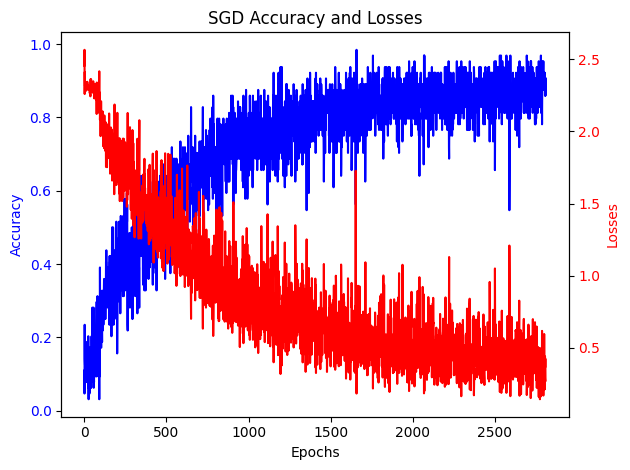

In [8]:
# Create the figure and the first axis
fig, ax1 = plt.subplots()
ax1.plot(sgd_accuracy, color='b', label='SGD Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(sgd_losses, color='r', label='SGD Losses')
ax2.set_ylabel('Losses', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('SGD Accuracy and Losses')
fig.tight_layout()  #
plt.show()

## Now, let's try a naive Gauss-Newton

We do 
1. Need to do adaptive tamping; B.3.1 from https://arxiv.org/pdf/1706.03662
2. Other people also do adaptive step size (B.2) from same paper.
3. Need better way to do layer by layer, since now they're somewhat different. 

In [21]:
def train_model_naive_precond(train_ds, model, params, learning_rate, num_epochs,
                   bsz:int = 64, use_initial: bool=False):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )

    @jax.jit
    def train_step(state, batch_X, labels):
        one_hot = jax.nn.one_hot(labels, 10)
        def loss_fn(params):
            logits = state.apply_fn(params, batch_X)
            loss = jnp.mean(optax.softmax_cross_entropy(logits=logits, labels=one_hot))
            return loss, logits

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, logits), grads = grad_fn({'params': state.params})

        if use_initial:
            jacobian = jax.jacobian(model.apply, argnums=0)(params, batch_X)['params']
        else:
            jacobian = jax.jacobian(model.apply, argnums=0)(
                {'params': state.params}, batch_X
            )['params']
        flattened, _ = jax.tree.flatten(
            jacobian
        )

        reshaped_leaves = [leaf.reshape(
            bsz * 10, 1, -1) for leaf in flattened]
        aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
        J = aggregated_array.reshape((bsz * 10, -1))
        # treescope.display(J)
        
        # Generalized Gauss-Newton is J^THJ
        probs = jax.nn.softmax(logits, axis=-1).flatten()
        diag_probs = jnp.diag(probs)
        outer_probs = jnp.outer(probs, probs)
        H = diag_probs - outer_probs

        flattened, back = jax.flatten_util.ravel_pytree(grads)
        altered = jnp.linalg.solve(J.T @ H @ J + 0.1 *  jnp.eye(J.shape[1]), flattened)
        grads = back(altered)

        state = state.apply_gradients(grads=grads['params'])

        accuracy = jnp.mean(jnp.argmax(logits, -1) == labels)
        return state, loss, accuracy
    
    print(f"Starting training for {num_epochs} epochs...")
    
    train_ds_size = len(train_ds['image'])
    steps_per_epoch = train_ds_size // bsz

    rng = jax.random.PRNGKey(0)
    perms = jax.random.permutation(rng, len(train_ds['image']))
    perms = perms[: steps_per_epoch * bsz]  # skip incomplete batch
    perms = perms.reshape((steps_per_epoch, bsz))

    epoch_loss = []
    epoch_accuracy = []
    
    for _ in tqdm(range(num_epochs)):
        for perm in tqdm(perms):
            batch_images = train_ds['image'][perm, ...]
            batch_labels = train_ds['label'][perm, ...]

            state, loss, accuracy = train_step(state, batch_images, batch_labels)
            epoch_loss.append(loss)
            epoch_accuracy.append(accuracy)
            
    return state, epoch_loss, epoch_accuracy

num_epochs = 3

key = jax.random.PRNGKey(0)

model = VisionTransformer(embed_dim=8, # Make these numbers small for testing first
                              hidden_dim=32,
                              num_heads=4,
                              num_channels=1,
                              num_layers=4,
                              num_classes=10,
                              patch_size=4,
                              num_patches=49,
                             )
params = model.init(key, jnp.ones((1, 28, 28, 1)))
print(sum(x.size for x in jax.tree.leaves(params['params'])))
 
# Train the model
trained_state_precond_naive, precond_losses_naive, precond_accuracy_naive = train_model_naive_precond(
    train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs
)

# Train the model
trained_state_precond_naive_init, precond_losses_naive_init, precond_accuracy_naive_init = train_model_naive_precond(
    train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs, use_initial=True
)

4138
Starting training for 3 epochs...


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

Starting training for 3 epochs...


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

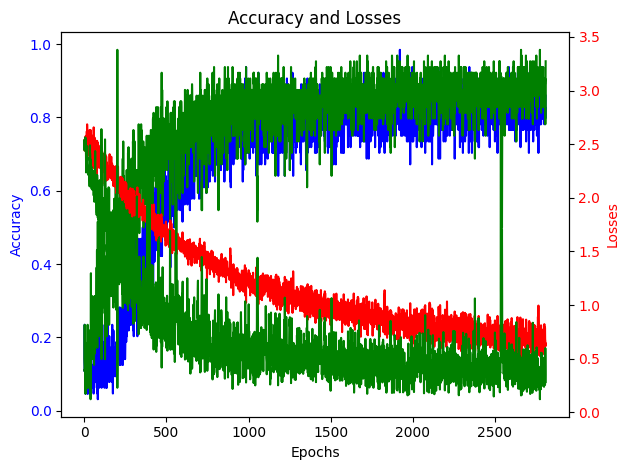

In [24]:
# Create the figure and the first axis
fig, ax1 = plt.subplots()
ax1.plot(precond_accuracy_naive, color='b', label='SGD Accuracy')
ax1.plot(precond_accuracy_naive_init, color='g', label='SGD Accuracy')
# ax1.plot(sgd_accuracy, color='b', label='SGD Accuracy')

ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(precond_losses_naive, color='r', label='SGD Losses')
ax2.plot(precond_losses_naive_init, color='g', label='SGD Losses')
# ax2.plot(sgd_losses, color='g', label='SGD Losses')

ax2.set_ylabel('Losses', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Accuracy and Losses')
fig.tight_layout()  #
plt.show()

## Gauss-Newton with layer approach 

In [14]:
lamb = 0.1
def train_model_precond(train_ds, model, params, learning_rate, num_epochs,
                   bsz:int = 64, use_initial: bool=False):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )
    
    # Grab each layer's things
    layer_jacobian = model.apply(
        {'params': state.params}, method=model.get_jacobian_calculators
    )
    # treescope.display(layer_jacobian)

    @jax.jit # This takes list, and makes them static; can be jitted easily
    def get_correction(k_list, global_adjoints, grad, H_inv, lamb: float=1e-1):
        """
        Assumes grad is a vector
        """
        p_list = [k.shape[1] for k in k_list]
        p_list.insert(0, 0)
        indices = list(itertools.accumulate(p_list))
        j_shape = global_adjoints[0].shape[0]

        # Save 
        j_i = []
        aux_var = jnp.zeros(j_shape)
        sum_mat = H_inv
        for i in range(len(k_list)):
            # Use the SMW formulation; first do Jv
            j_i.append(global_adjoints[i] @ k_list[i])
            sum_mat += j_i[i] @ j_i[i].T / lamb
            aux_var += j_i[i] @ grad[indices[i]:indices[i+1]]
        aux_var = jnp.linalg.solve(sum_mat, aux_var)
        
        # Finally do J^T v and scale
        # out = jnp.concat([k_list[i].T @ (global_adjoints[i].T @ aux_var) for i in range(len(k_list))]) / (lamb ** 2)
        out = jnp.concat([j_i[i].T @ aux_var for i in range(len(k_list))]) / (lamb ** 2)

        # Don't forget the 1/lambda I
        return -out + grad / lamb

    @jax.jit
    def train_step(state, batch_X, labels):
        one_hot = jax.nn.one_hot(labels, 10)
        def loss_fn(params):
            logits, layer_vals  = state.apply_fn(params, batch_X, layer_out=True)
            loss = jnp.mean(optax.softmax_cross_entropy(logits=logits, labels=one_hot))
            return loss, (logits, layer_vals)

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, (logits, layer_vals)), grads = grad_fn({'params': state.params})

        # Get the corrections 
        flattened_grads, back = jax.flatten_util.ravel_pytree(grads)

        # Generalized Gauss-Newton is J^THJ
        # First calculate H; this is a diagonal 
        probs = jax.nn.softmax(logits, axis=-1).flatten()
        diag_probs = jnp.diag(probs)
        diag_probs_inv = jnp.diag(1 / probs)  # Inverse of the diagonal matrix
        outer_probs = jnp.outer(probs, probs)
        denominator = 1 - jnp.dot(probs, jnp.dot(diag_probs_inv, probs))
        numerator = jnp.dot(diag_probs_inv, outer_probs) @ diag_probs_inv
        H_inv = diag_probs_inv + numerator / denominator

        # Calculate the Jacobian wrt adjoints
        if use_initial:
            jacobian = jax.jacrev(
                lambda params, perturbations, batch_X: model.apply(
                    {'params': params, 'perturbations': perturbations}, batch_X
                ),
                argnums=1
            )(
                params['params'], params['perturbations'], batch_X 
            )
        else:
            jacobian = jax.jacrev(
                lambda params, perturbations, batch_X: model.apply(
                    {'params': params, 'perturbations': perturbations}, batch_X
                ),
                argnums=1
            )(
                state.params, params['perturbations'], batch_X
            )

        flattened, _ = jax.tree.flatten(
            jacobian
        )
        global_adjoints = [leaf.reshape((leaf.shape[0] * leaf.shape[1], -1)) for leaf in flattened]

        # Now do the layer calculations
        layers = []
        for i, (jac_fn, layer_input) in enumerate(zip(layer_jacobian, layer_vals)):
            if use_initial:
                layer_params = params['params'][f'layers_{i}']
            else:
                layer_params = state.params[f'layers_{i}']
                
            jacobian_pytree = jac_fn(layer_params, layer_input)            
            layer_weights = jax.tree.flatten(jacobian_pytree)[0]
            layer_weights = [weights.reshape((global_adjoints[i].shape[1], -1)) for weights in layer_weights]
            layer_weights = jnp.concatenate(layer_weights, axis=-1)
            layers.append(layer_weights)

        corrected = get_correction(layers, global_adjoints, flattened_grads, H_inv, 0.1)
        grads = back(corrected)

        state = state.apply_gradients(grads=grads['params'])
        accuracy = jnp.mean(jnp.argmax(logits, -1) == labels)
        return state, loss, accuracy
    
    print(f"Starting training for {num_epochs} epochs...")
    
    train_ds_size = len(train_ds['image'])
    steps_per_epoch = train_ds_size // bsz

    rng = jax.random.PRNGKey(0)
    perms = jax.random.permutation(rng, len(train_ds['image']))
    perms = perms[: steps_per_epoch * bsz]  # skip incomplete batch
    perms = perms.reshape((steps_per_epoch, bsz))

    epoch_loss = []
    epoch_accuracy = []
    
    for _ in tqdm(range(num_epochs)):
        for perm in tqdm(perms):
            batch_images = train_ds['image'][perm, ...]
            batch_labels = train_ds['label'][perm, ...]

            state, loss, accuracy = train_step(state, batch_images, batch_labels)
            epoch_loss.append(loss)
            epoch_accuracy.append(accuracy)
            
    return state, epoch_loss, epoch_accuracy

num_epochs = 1

key = jax.random.PRNGKey(0)
model =  VisionTransformer(embed_dim=8, # Make these numbers small for testing first
                              hidden_dim=32,
                              num_heads=4,
                              num_channels=1,
                              num_layers=4,
                              num_classes=10,
                              patch_size=4,
                              num_patches=49,
                             )

# Hmm, input must match batch size? 
bsz = 64
params = model.init(key, jnp.ones((bsz, 28, 28, 1)))
print(sum(x.size for x in jax.tree.leaves(params['params'])))
 
# Train the model
# trained_state_precond_init, precond_losses_init, precond_accuracy_init = train_model_precond(
#     train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs, bsz=bsz, use_initial=True
# )

jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
trained_state_precond, precond_losses, precond_accuracy = train_model_precond(
    train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs, bsz=bsz, use_initial=False
)

print('Done')

4138
Starting training for 1 epochs...


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

2025-08-12 12:14:49.253357: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3425] Can't reduce memory use below 56.47GiB (60629837455 bytes) by rematerialization; only reduced to 1.58TiB (1740269545676 bytes), down from 1.58TiB (1740297970468 bytes) originally
2025-08-12 12:15:04.893283: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.58TiB (rounded to 1740285301504)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-08-12 12:15:04.894774: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] *___________________________________________________________________________________________________
E0812 12:15:04.894801  231216 pjrt_stream_executor_client.cc:2939] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory w

XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 1740285301464 bytes.

Starting training for 1 epochs...


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

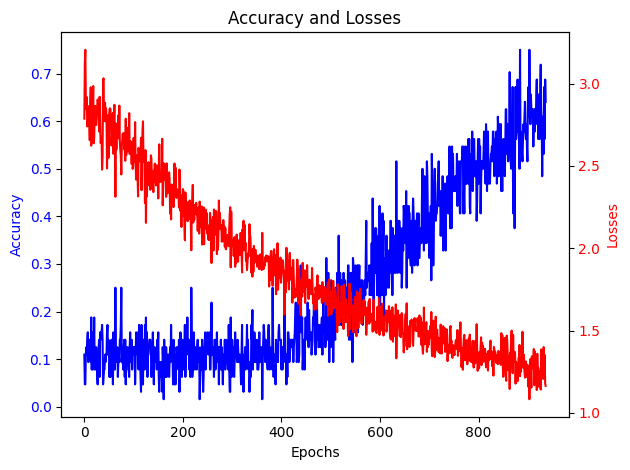

In [10]:
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
trained_state_precond, precond_losses, precond_accuracy = train_model_precond(
    train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs, bsz=bsz, use_initial=False
)

# Create the figure and the first axis
fig, ax1 = plt.subplots()
ax1.plot(precond_accuracy, color='b', label='Precond Accuracy')
# ax1.plot(precond_accuracy_init, color='b', label='Precond Accuracy')
# ax1.plot(precond_accuracy_naive_init, color='g', alpha=.5,label='Precond Accuracy')

# ax1.plot(sgd_accuracy, color='g', label='SGD Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(precond_losses, color='r', label='SGD Losses')
# ax2.plot(precond_losses_init, color='r', label='SGD Losses')
# ax2.plot(precond_losses_naive_init, color='g', alpha=.2, label='SGD Losses')

ax2.set_ylabel('Losses', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Accuracy and Losses')
fig.tight_layout()  #
plt.show()

Starting training for 1 epochs...


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

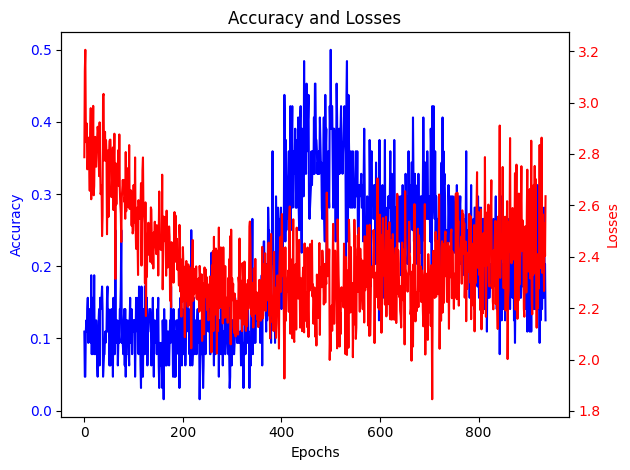

In [12]:
jax.config.update("jax_enable_x64", False)
jax.config.update('jax_default_matmul_precision', 'default')
train_ds, test_ds = get_datasets()
trained_state_precond, precond_losses, precond_accuracy = train_model_precond(
    train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs, bsz=bsz, use_initial=False
)

# Create the figure and the first axis
fig, ax1 = plt.subplots()
ax1.plot(precond_accuracy, color='b', label='Precond Accuracy')
# ax1.plot(precond_accuracy_init, color='b', label='Precond Accuracy')
# ax1.plot(precond_accuracy_naive_init, color='g', alpha=.5,label='Precond Accuracy')

# ax1.plot(sgd_accuracy, color='g', label='SGD Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(precond_losses, color='r', label='SGD Losses')
# ax2.plot(precond_losses_init, color='r', label='SGD Losses')
# ax2.plot(precond_losses_naive_init, color='g', alpha=.2, label='SGD Losses')

ax2.set_ylabel('Losses', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Accuracy and Losses')
fig.tight_layout()  #
plt.show()

# Let's do some timings... why is this slower? 